# **Data Exploration**

<span style="color:red">**Note:** </span>This notebook is paired with a Python script using **Jupytext**.  
 - The `.ipynb` is the primary artifact for exploration and explanation.  
 - A synchronized `.py` file is maintained for reproducibility and review.  
 - To manually sync all notebooks, run the alias `syncnb`.  
 - The project does not require Jupytext to run; the paired `.py` files are already committed.

<h2 style="color:cyan">1. Setup and Schema Discovery</h2>

(base paths, duckdb, verify tables, excluded tables, schema catalog, joinable tables, data types)

### Setting base paths

In [76]:
from pathlib import Path

# Base paths
PROJECT_ROOT = Path("/root/icu_mortality_takehome")
DATA_DIR = PROJECT_ROOT / "data" / "raw" / "eicu"

# Printing base path and checking if it exists
DATA_DIR, DATA_DIR.exists()

(PosixPath('/root/icu_mortality_takehome/data/raw/eicu'), True)

### DuckDB setup using SQLite extension

 - DuckDB is used as the query engine
 - SQLite remains the storage layer
 - No data is copied or transformed at this stage
 - Queries are executed directly against the SQLite file

In [77]:
import duckdb

# Path to the SQLite database file provided by PhysioNet
SQLITE_DB = DATA_DIR / "eicu_v2_0_1.sqlite3"

# Create an in-memory DuckDB connection for analytical queries
con = duckdb.connect()

# Enable DuckDB's SQLite extension for direct SQLite queries
con.execute("INSTALL sqlite;")
con.execute("LOAD sqlite;")

# Confirm the database file exists
SQLITE_DB, SQLITE_DB.exists()

(PosixPath('/root/icu_mortality_takehome/data/raw/eicu/eicu_v2_0_1.sqlite3'),
 True)

### Verify table names

In [78]:
# Query to list all tables in the SQLite database using DuckDB's SQLite extension
all_tables = con.execute(
    f"""
    SELECT
        name AS table_name
    FROM sqlite_scan('{SQLITE_DB}', 'sqlite_master')
    WHERE type = 'table'
    ORDER BY name
    """
).df()

# Printing all tables in the SQLite database
all_tables

,table_name
0,admissiondrug
1,admissiondx
2,allergy
3,apacheapsvar
4,apachepatientresult
5,apachepredvar
6,careplancareprovider
7,careplaneol
8,careplangeneral
9,careplangoal


### Define out-of-scope tables

Certain tables in the eICU database contain engineered severity scores or
model-derived predictions that are downstream of the outcome of interest.
These tables are excluded up front to prevent target leakage and to keep
the modeling task focused on learning from raw clinical text.
<br><br>

<span style="color:red">**Note:** </span> Exclusion of Apache-derived tables:

All Apache-derived tables (`apacheapsvar`, `apachepredvar`, `apachepatientresult`)
are excluded from feature construction.

These tables contain engineered severity scores and model-derived predictions
that are downstream of the outcome being predicted. Including them would
introduce direct target leakage and undermine the goal of learning from raw
clinical text.


In [79]:
# Tables excluded due to target leakage or downstream modeling
EXCLUDED_TABLES = {
    "apacheapsvar",
    "apachepredvar",
    "apachepatientresult",
}

# Check that excluded tables are present in the database
set(EXCLUDED_TABLES).intersection(set(all_tables["table_name"]))

# Remove excluded tables from further consideration
all_tables = all_tables[
    ~all_tables["table_name"].isin(EXCLUDED_TABLES)
].reset_index(drop=True)

### Building a schema catalog

Creating a complete list of all columns across all tables, using LIMIT 0 which doesn't read data, only the schema gets returned. <br>
This includes DuckDB data type for identifying relevant fields.

In [80]:
import pandas as pd

def table_schema(table_name: str) -> list[dict]:
    """
    Return column names and data types for a table without scanning any data.
    Uses LIMIT 0 to resolve schema only, then reads column metadata from
    cur.description, which returns a list of tuples where each tuple's
    first element is the column name and second is the inferred type.
    """
    q = f"SELECT * FROM sqlite_scan('{SQLITE_DB}', '{table_name}') LIMIT 0"
    cur = con.execute(q)

    rows = []
    for col in cur.description:
        rows.append({
            "table_name": table_name,
            "column_name": col[0].lower(),  # Column name (cleaned to lowercase)
            "duckdb_type": str(col[1])  # DuckDB-inferred type (e.g., INTEGER, VARCHAR)
        })

    return rows

schema_rows = []

# Iterate through every table discovered in sqlite_master (already in all_tables)
for t in all_tables["table_name"]:
    # Collect column names and inferred data types for each table
    schema_rows.extend(table_schema(t))

# Create a schema dataframe listing every column and its inferred type
schema = pd.DataFrame(schema_rows)

# Check the first few rows of the schema dataframe
schema.head()

,table_name,column_name,duckdb_type
0,admissiondrug,admissiondrugid,BIGINT
1,admissiondrug,patientunitstayid,BIGINT
2,admissiondrug,drugoffset,BIGINT
3,admissiondrug,drugenteredoffset,BIGINT
4,admissiondrug,drugnotetype,VARCHAR


### Identify joinable tables

Tables that include patientunitstayid.<br><br>
The modeling unit for this project is one ICU stay. Filtering to tables that contain patientunitstayid ensures candidate feature tables can be joined to the label table at the correct grain without row duplication.

In [81]:
# Identify tables that contain the ICU-stay join key (patientunitstayid)
tables_with_stay_key = set(
    schema[schema["column_name"] == "patientunitstayid"]["table_name"]
)

# Check number of tables that can join to labels, check first 10
len(tables_with_stay_key), sorted(list(tables_with_stay_key))[:10]

(27,
 ['admissiondrug',
  'admissiondx',
  'allergy',
  'careplancareprovider',
  'careplaneol',
  'careplangeneral',
  'careplangoal',
  'careplaninfectiousdisease',
  'customlab',
  'diagnosis'])

### Identify DuckDB data types 

This will help narrow down potential columns to use for text based data.

In [82]:
# Distinct DuckDB types with counts (clean column names)
type_counts = (
    schema["duckdb_type"]
    .value_counts()
    .rename_axis("data_type")
    .reset_index(name="count")
)

# View distinct data types and their counts across all tables
type_counts

,data_type,count
0,VARCHAR,128
1,BIGINT,124
2,DOUBLE,39


<h2 style="color:cyan">2. Text Field Classification</h2>

(candidate text columns, automated screening, profiling, bucketing,
manual review, overrides, verification)

### Identify candidate text columns using DuckDB-inferred data types

DuckDB typically maps SQLite text fields to VARCHAR, which is confirmed above. <br>
This provides a schema-level signal for string-based features. <br>
It also filters on tables that include the stay key.

In [83]:
# DuckDB maps SQLite string-based fields to VARCHAR in this dataset.
# These columns are strong candidates for free-text or semi-structured
# clinical information suitable for NLP-based feature extraction.
text_type = "VARCHAR"

# Identify candidate text columns by:
# 1. Selecting columns inferred as VARCHAR by DuckDB
# 2. Restricting to tables that include the ICU-stay join key (patientunitstayid), ensuring features can be joined at the correct unit of analysis
candidate_text_cols = (
    schema[
        (schema["duckdb_type"] == text_type)
        & (schema["table_name"].isin(tables_with_stay_key))
    ][["table_name", "column_name", "duckdb_type"]]
    .drop_duplicates()
    .sort_values(["table_name", "column_name"])
    .reset_index(drop=True)
)

# Preview candidate text columns
candidate_text_cols.head(20)

,table_name,column_name,duckdb_type
0,admissiondrug,drugadmitfrequency,VARCHAR
1,admissiondrug,drugname,VARCHAR
2,admissiondrug,drugnotetype,VARCHAR
3,admissiondrug,drugunit,VARCHAR
4,admissiondrug,rxincluded,VARCHAR
5,admissiondrug,specialtytype,VARCHAR
6,admissiondrug,usertype,VARCHAR
7,admissiondrug,writtenineicu,VARCHAR
8,admissiondx,admitdxname,VARCHAR
9,admissiondx,admitdxpath,VARCHAR


### Automated screening of text fields

Before manual inspection, each candidate text column is sampled and profiled
using lightweight signals that capture how the field behaves in practice:

- **Text length distribution** (avg + p90): Separates narrative from short labels
- **Numeric-like value frequency**: Catches measurements stored as text
- **Whitespace presence**: Proxy for multi-token clinical language
- **Delimiter frequency**: Detects hierarchical pipe/arrow-delimited paths
- **Uniqueness rate**: Distinguishes descriptive language from repeated codes

No columns are excluded at this stage. The intent is to organize the candidate
fields before making modeling decisions.

In [84]:
import re
import pandas as pd

# Regular expression for detecting numeric-like text

# This pattern matches:
# - integers (e.g., "12")
# - decimals (e.g., "3.14")
# - comparison-prefixed values (e.g., ">100", "<10.5")

NUMERIC_REGEX = re.compile(
    r"""^
    \s*
    [<>]?\s*
    [-+]?
    (\d+(\.\d+)?|\.\d+)
    \s*
    $""",
    re.VERBOSE,
)

# Hierarchical delimiter pattern for eICU structured text fields
#
# Matches "|" (pipe) and ">" when used as category path separators.
# The ">" pattern excludes ">=" comparisons to avoid false positives
# on numeric-like fields that use comparison operators.

DELIMITER_REGEX = re.compile(r"[|]|(?<!\s)>(?!\s*=)")


def text_profile(table_name: str, column_name: str, n: int = 300) -> dict:
    """
    Sample values from a text column and compute lightweight profiling
    statistics to help distinguish between:
      - narrative clinical text,
      - short categorical labels,
      - hierarchical structured text (pipe/arrow-delimited paths),
      - and numeric values stored as text

    This function intentionally samples a limited number of rows to
    avoid scanning large tables while still providing representative
    signals for feature triage.
    """
    
    # Query non-null, non-empty values from the target column.
    # LIMIT is used to keep profiling fast and inexpensive.
    q = f"""
    SELECT CAST({column_name} AS VARCHAR) AS v
    FROM sqlite_scan('{SQLITE_DB}', '{table_name}')
    WHERE {column_name} IS NOT NULL
      AND TRIM(CAST({column_name} AS VARCHAR)) <> ''
    LIMIT {n}
    """
    s = con.execute(q).df()["v"]

    # Handle columns with no non-empty values in the sample
    if s.empty:
        return {
            "sample_n": 0,
            "avg_len": 0.0,
            "p90_len": 0.0,
            "pct_numeric_like": 0.0,
            "pct_contains_space": 0.0,
            "pct_contains_delimiter": 0.0,
            "unique_rate": 0.0,
        }

    # Character length distribution
    lengths = s.str.len()

    return {
        # Number of sampled non-empty values
        "sample_n": len(s),

        # Average string length (short labels vs longer text)
        "avg_len": float(lengths.mean()),

        # 90th percentile length (helps identify long narrative fields),
        # using this instead of max to reduce sensitivity to outliers
        "p90_len": float(lengths.quantile(0.90)),

        # Fraction of values that look numeric despite being stored as text
        "pct_numeric_like": float(
            s.apply(lambda x: bool(NUMERIC_REGEX.match(x))).mean()
        ),

        # Fraction of values containing whitespace (proxy for multi-word text)
        "pct_contains_space": float(s.str.contains(r"\s").mean()),

        # Fraction of values containing hierarchical delimiters ("|" or ">")
        # High values (> 0.5) indicate structured category paths rather than
        # free-form language, even when length and space signals look narrative
        "pct_contains_delimiter": float(
            s.apply(lambda x: bool(DELIMITER_REGEX.search(x))).mean()
        ),

        # Proportion of unique values in the sample
        # High uniqueness often indicates narrative text; low uniqueness
        # suggests categorical labels or templated entries
        "unique_rate": float(s.nunique() / len(s)),
    }

### Profile every candidate text column

In [85]:
# Run profiling across all candidate text columns (VARCHAR + joinable tables)
profiles = []

for r in candidate_text_cols.itertuples(index=False):
    stats = text_profile(r.table_name, r.column_name, n=300)
    profiles.append({
        "table_name": r.table_name,
        "column_name": r.column_name,
        **stats
    })

text_profiles = pd.DataFrame(profiles)

# Quick sanity check
text_profiles.head()

,table_name,column_name,sample_n,avg_len,p90_len,pct_numeric_like,pct_contains_space,pct_contains_delimiter,unique_rate
0,admissiondrug,drugadmitfrequency,300,6.203333,11.0,0.0,0.213333,0.0,0.016667
1,admissiondrug,drugname,300,255.000000,255.0,0.0,1.000000,0.0,0.516667
2,admissiondrug,drugnotetype,300,12.690000,22.0,0.0,0.316667,0.0,0.010000
3,admissiondrug,drugunit,300,4.643333,9.0,0.0,0.086667,0.0,0.020000
4,admissiondrug,rxincluded,300,4.133333,5.0,0.0,0.000000,0.0,0.006667


### Join profiling stats back onto the candidate list

In [86]:
candidate_text_cols_profiled = candidate_text_cols.merge(
    text_profiles,
    on=["table_name", "column_name"],
    how="left"
)

# View profiled candidate text columns with statistics
candidate_text_cols_profiled.head()

,table_name,column_name,duckdb_type,sample_n,avg_len,p90_len,pct_numeric_like,pct_contains_space,pct_contains_delimiter,unique_rate
0,admissiondrug,drugadmitfrequency,VARCHAR,300,6.203333,11.0,0.0,0.213333,0.0,0.016667
1,admissiondrug,drugname,VARCHAR,300,255.000000,255.0,0.0,1.000000,0.0,0.516667
2,admissiondrug,drugnotetype,VARCHAR,300,12.690000,22.0,0.0,0.316667,0.0,0.010000
3,admissiondrug,drugunit,VARCHAR,300,4.643333,9.0,0.0,0.086667,0.0,0.020000
4,admissiondrug,rxincluded,VARCHAR,300,4.133333,5.0,0.0,0.000000,0.0,0.006667


### Bucketing text fields by intended modeling treatment

Text fields are grouped into buckets based on profiling signals so that each
type gets appropriate treatment rather than forcing all VARCHAR columns through
the same pipeline:

- **narrative_text**: free-form clinical language
- **categorical_text**: short, repetitive labels
- **hierarchical_structured_text**: pipe/arrow-delimited category paths
- **mixed_text**: contains both short labels and narrative within the same column
- **numeric_text_artifact**: measurements stored as text

Thresholds are chosen to separate clearly different text behaviors, not to
optimize model performance. Final inclusion decisions are validated through
manual review.

In [87]:
def classify_text_column(row) -> str:
    """
    Classify a text column into a modeling bucket based on profiling signals.

    Evaluation order is intentional (most confident → least confident):
      numeric → hierarchical → narrative → mixed → categorical

    hierarchical_structured_text is checked before narrative because
    hierarchical fields have high p90_len and pct_contains_space, which
    would otherwise trigger the narrative bucket incorrectly.

    mixed_text captures fields that show some narrative characteristics
    but don't fully qualify. Labeling them as mixed defers the routing
    decision to feature engineering.
    """

    # Numeric values stored as text
    #
    # Rationale for pct_numeric_like > 0.6:
    # - Majority of sampled entries are numeric, indicating the column
    #   semantically represents measurements even though stored as VARCHAR.
    # - Using 0.6 rather than higher biases toward early exclusion,
    #   reducing the risk of applying NLP to numeric artifacts.
    
    if row["pct_numeric_like"] > 0.6:
        return "numeric_text_artifact"

    # Path columns in this dataset contain hierarchical clinical content
    # (pipe or slash-delimited category paths), not system metadata.
    # Classified as hierarchical structured text for delimiter replacement.
    if row["column_name"].lower().endswith("path"):
        return "hierarchical_structured_text"

    # Hierarchical structured text
    #
    # Rationale for pct_contains_delimiter > 0.5:
    # - diagnosisstring and treatmentstring are near 1.0 in practice,
    #   so 0.5 catches them comfortably while avoiding false positives
    #   on narrative text that occasionally contains ">" characters.
    #
    # Checked BEFORE narrative because hierarchical fields have high
    # p90_len and pct_contains_space, which would otherwise trigger
    # the narrative bucket incorrectly.
    
    if row["pct_contains_delimiter"] > 0.5:
        return "hierarchical_structured_text"

    # Narrative clinical text
    #
    # All three conditions must hold simultaneously:
    #   p90_len >= 50               sustained long-form content, not rare outliers
    #   pct_contains_space >= 0.4   multi-token language
    #   unique_rate >= 0.3          descriptive, non-repetitive
   
    if (
        row["p90_len"] >= 50
        and row["pct_contains_space"] >= 0.4
        and row["unique_rate"] >= 0.3
    ):
        return "narrative_text"

    # Mixed text
    #
    # Fields that show some narrative characteristics but don't fully qualify.
    # Contains a mix of short categorical labels and longer descriptive text
    # within the same column (e.g., notevalue has both "oriented x3" and
    # multi-sentence clinical assessments).
    #
    # The key differentiator from categorical is the length spread ratio
    # (p90 / avg). A pure categorical field clusters tightly around one
    # length. A mixed field has both short and long values, producing a
    # fat right tail in the length distribution.
    #
    # Rationale for thresholds:
    #   pct_contains_space >= 0.2   at least some values are multi-word
    #   unique_rate >= 0.15         not a pure code column
    #   p90_len >= 20               upper tail extends beyond trivial labels
    #   length_spread >= 1.8        short and long values coexist
    #
    # These fields get split handling at feature engineering time:
    # short values → categorical treatment, long values → NLP treatment,
    # or segmented by a grouping column (e.g., notetype).
    
    avg = row["avg_len"]
    p90 = row["p90_len"]
    length_spread = (p90 / avg) if avg > 0 else 1.0

    if (
        row["pct_contains_space"] >= 0.2
        and row["unique_rate"] >= 0.15
        and p90 >= 20
        and length_spread >= 1.8
    ):
        return "mixed_text"

    # Remaining fields behave like short, structured, or semi-structured labels
    return "categorical_text"


# Apply classification
candidate_text_cols_profiled["text_bucket"] = (
    candidate_text_cols_profiled.apply(classify_text_column, axis=1)
)

# Inspect distribution across buckets
candidate_text_cols_profiled["text_bucket"].value_counts()

text_bucket
categorical_text                86
numeric_text_artifact           23
hierarchical_structured_text     9
mixed_text                       6
narrative_text                   2
Name: count, dtype: int64

### Manual review queue for ambiguous or high-impact fields

Rather than manually inspecting every single text column at this point, a targeted review
queue is constructed to focus attention where it matters most.

Columns are flagged for manual review if they:
- are classified as narrative text,
- sit near classification thresholds,
- or are explicitly recommended as text sources in the problem statement
  (for example diagnosis, admissiondx, note, and pasthistory tables).

This produces a concise, defensible set of columns requiring human
judgment before final inclusion decisions are made.

In [88]:
def sample_values_compact(table_name: str, column_name: str, n: int = 5) -> list[str]:
    """
    Pull a small set of DISTINCT, non-empty example values from a column.

    Purpose:
    - This is a lightweight "peek" utility for manual review.
    - DISTINCT helps avoid showing the same repeated label over and over.
    - LIMIT keeps this fast and avoids scanning large tables.

    Notes:
    - Intended for review/debugging only, not for training.
    - We do not order by anything here, so the specific examples returned are not guaranteed
      to be representative. They are just enough to quickly sanity-check what the column contains.
    """
    q = f"""
    SELECT DISTINCT CAST({column_name} AS VARCHAR) AS v
    FROM sqlite_scan('{SQLITE_DB}', '{table_name}')
    WHERE {column_name} IS NOT NULL
      AND TRIM(CAST({column_name} AS VARCHAR)) <> ''
    LIMIT {n}
    """
    df = con.execute(q).df()
    return df["v"].tolist()


# -------------------------------------------------------------------
# Build a manual review queue for text fields
#
# Goal:
# - Automated bucketing is a first pass. This queue surfaces "high risk" or
#   "ambiguous" fields for human inspection.
#
# Why these filters:
# - narrative_text: high value, higher leakage risk (notes, assessments)
# - pct_numeric_like in [0.3, 0.6]: mixed columns (could be numeric-as-text or templated strings)
# - unique_rate in [0.2, 0.4]: borderline between repetitive categorical labels and richer text
# - recommended tables: explicitly suggested sources in the problem statement; we force review
#   so we can justify inclusion/exclusion and decide treatment (categorical vs narrative)
#
# Convenience:
# - We sort by text_bucket first so review can happen in coherent batches
#   (all narrative together, all hierarchical together, etc.).
# -------------------------------------------------------------------

review_queue = candidate_text_cols_profiled[
    (candidate_text_cols_profiled["text_bucket"] == "narrative_text")
    | (candidate_text_cols_profiled["text_bucket"] == "mixed_text")
    | (candidate_text_cols_profiled["text_bucket"] == "hierarchical_structured_text")
    | (candidate_text_cols_profiled["pct_numeric_like"].between(0.3, 0.6))
    | (candidate_text_cols_profiled["unique_rate"].between(0.2, 0.4))
    | (candidate_text_cols_profiled["table_name"].isin(
        ["diagnosis", "admissiondx", "note", "pasthistory"]
    ))
].copy()

# Attach a few example values to each queued column for fast manual inspection.
# This makes it easier to spot:
# - numeric measurements stored as strings (e.g., "38.2", ">1000")
# - hierarchical fields (paths, UI labels)
# - templated phrases vs true narrative language

review_queue["sample_values"] = review_queue.apply(
    lambda r: sample_values_compact(r.table_name, r.column_name, n=5),
    axis=1
)

# Keep the most useful signals + examples, then sort for a cleaner review workflow.
# Sorting by text_bucket first keeps similar feature types together.

review_queue = (
    review_queue[
        [
            "table_name",
            "column_name",
            "text_bucket",
            "avg_len",
            "p90_len",
            "pct_numeric_like",
            "unique_rate",
            "sample_values",
        ]
    ]
    .sort_values(["text_bucket", "table_name", "column_name"])
    .reset_index(drop=True)
)

# View full df
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

review_queue

,table_name,column_name,text_bucket,avg_len,p90_len,pct_numeric_like,unique_rate,sample_values
0,diagnosis,activeupondischarge,categorical_text,4.646667,5.0,0.000000,0.006667,"[True, False]"
1,diagnosis,diagnosispriority,categorical_text,5.466667,7.0,0.000000,0.010000,"[Primary, Major, Other]"
2,diagnosis,icd9code,categorical_text,12.553333,14.0,0.050000,0.240000,"[427.31, I48.0, 518.83, J96.10, 785.51, R57.0, 251.1, E16.2, 599.0, N39.0]"
3,medication,drugname,categorical_text,37.000000,54.0,0.000000,0.216667,"[PRAVASTATIN SODIUM 40 MG PO TABS, GABAPENTIN 100 MG PO CAPS, CLONIDINE HCL 0.1 MG PO TABS, METOPROLOL SUCCINATE ER 50 MG PO TB24, GLUCOSE]"
4,medication,loadingdose,categorical_text,100.000000,100.0,0.000000,0.250000,"[0 mg , 150 ml ]"
5,microlab,antibiotic,categorical_text,12.014388,20.0,0.000000,0.208633,"[nitrofurantoin, ertapenem, piperacillin/tazobactam, amoxicillin/clavulonic acid, imipenem/cilastatin]"
6,note,notetext,categorical_text,7.336667,12.0,0.380000,0.026667,"[SystemView, This procedure was performed independently of the time included in today's admission/progress note(s), Agitation/anxiety - evaluation and management, Shock - evaluation and management, < 20 pack years - still smoking]"
7,note,notetype,categorical_text,21.930000,22.0,0.000000,0.010000,"[Re-Admission, Paracentesis, Follow-up Consultation/Other, Dialysis Catheter, Daily Progress]"
8,note,notevalue,categorical_text,9.550000,12.0,0.000000,0.026667,"[This procedure was performed independently of the time included in today's admission/progress note(s), Agitation/anxiety - evaluation and management, Shock - evaluation and management, < 20 pack years - still smoking, negative]"
9,pasthistory,pasthistorynotetype,categorical_text,22.000000,22.0,0.000000,0.003333,"[Re-Admission, Follow-up Consultation/Other, Admission, Comprehensive Progress, Initial Consultation/Other]"


### Manual overrides and final classification

Manual overrides document deviations from automated bucketing based on
sample inspection, domain understanding, and modeling intent.

This includes reclassifications (e.g., fields that behave differently
than profiling suggests), removal of duplicate columns, and exclusion
of discharge-time fields identified as target leakage during
verification of the initial classification pass.

Each override records the final bucket and rationale, creating a
transparent audit trail.

In [89]:
manual_overrides = pd.DataFrame(
    [
        # Reclassifications based on sample inspection
        ("admissiondrug", "drugname", "categorical_text",
         "Fixed-width padded drug names, not narrative language"),
        
        ("intakeoutput", "celllabel", "REMOVE",
         "Leaf value of cellpath. Redundant once the full hierarchical "
         "path is included."),

        ("note", "notevalue", "REMOVE",
         "Leaf value of notepath. Predominantly UI labels and short "
         "phrases already captured in the hierarchical path."),

        ("nursecharting", "nursingchartcelltypevalname", "REMOVE",
         "Either duplicates nursingchartcelltypevallabel or contains "
         "the generic placeholder 'Value'. No additional signal."),

        ("patient", "hospitaladmittime24", "REMOVE",
         "Timestamp, not a text feature."),

        ("patient", "unitadmittime24", "REMOVE",
         "Timestamp, not a text feature."),     

        ("careplangoal", "cplgoalvalue", "mixed_text",
         "Clinical goal statements range from short labels to descriptive "
         "phrases. Override from categorical to mixed for split handling."),

        ("careplangeneral", "cplitemvalue", "mixed_text",
         "Clinical care plan items range from single words to descriptive "
         "phrases. Override from categorical to mixed for split handling."),

        ("medication", "dosage", "numeric_text_artifact",
         "Numeric dose values stored as text. Auto-classifier missed "
         "due to space-separated dose-unit format (e.g., '5 3')."),

        ("medication", "drugivadmixture", "REMOVE",
         "Binary Yes/No flag. No NLP signal."),

        ("medication", "drugordercancelled", "REMOVE",
         "Binary Yes/No flag. No NLP signal."),

        ("medication", "loadingdose", "REMOVE",
         "Mostly empty. No meaningful text content."),

        ("medication", "prn", "REMOVE",
         "Binary Yes/No flag. Already captured in frequency column."),
      
        # Duplicates
        ("admissiondx", "admitdxname", "REMOVE",
         "Duplicate of admitdxtext and Redundant with admitdxpath which provides "
         "the full hierarchical context. The text field is just the leaf value."),

        ("admissiondx", "admitdxtext", "REMOVE",
         "Redundant with admitdxpath which provides the full hierarchical "
         "context. The text field is just the leaf value."),

        ("pasthistory", "pasthistoryvalue", "REMOVE",
         "Leaf value of pasthistorypath. Redundant once the full "
         "hierarchical path is included."),

        ("physicalexam", "physicalexamvalue", "REMOVE",
         "Leaf value of physicalexampath. Redundant once the full "
         "hierarchical path is included."),

        ("note", "notetext", "REMOVE",
         "Near-duplicate of notevalue"),

        ("pasthistory", "pasthistoryvaluetext", "REMOVE",
         "Near-duplicate of pasthistoryvalue"),

        # Not a clinical feature
        ("diagnosis", "icd9code", "REMOVE",
         "Billing code, not in scope for clinical text features"),

        ("patient", "uniquepid", "REMOVE",
         "Patient identifier, not a clinical feature"),

        ("lab", "labmeasurenameinterface", "REMOVE",
         "Unit of measurement (e.g., %, g/dL). No clinical signal "
         "beyond what labname already provides."),

        ("lab", "labmeasurenamesystem", "REMOVE",
         "Unit of measurement (e.g., K/mcL, mmol/L). No clinical signal "
         "beyond what labname already provides."),         

        # Target leakage: Apache-derived
        ("patient", "apacheadmissiondx", "REMOVE",
         "Apache admission diagnosis directly encodes mortality risk"),

        # Target leakage: discharge-time fields
        # These are only known at or after discharge and would leak the outcome.
        ("patient", "hospitaldischargestatus", "REMOVE",
         "Target variable, not a feature"),

        ("patient", "hospitaldischargelocation", "REMOVE",
         "Leakage: only known at discharge"),

        ("patient", "hospitaldischargetime24", "REMOVE",
         "Leakage: only known at discharge"),

        ("patient", "unitdischargestatus", "REMOVE",
         "Leakage: only known at discharge"),

        ("patient", "unitdischargelocation", "REMOVE",
         "Leakage: only known at discharge"),

        ("patient", "unitdischargetime24", "REMOVE",
         "Leakage: only known at discharge"),

        ("diagnosis", "activeupondischarge", "REMOVE",
         "Leakage: only known at discharge"),

        ("careplancareprovider", "activeupondischarge", "REMOVE",
         "Leakage: only known at discharge"),

        ("careplaneol", "activeupondischarge", "REMOVE",
         "Leakage: only known at discharge"),

        ("careplangeneral", "activeupondischarge", "REMOVE",
         "Leakage: only known at discharge"),

        ("careplangoal", "activeupondischarge", "REMOVE",
         "Leakage: only known at discharge"),

        ("careplaninfectiousdisease", "activeupondischarge", "REMOVE",
         "Leakage: only known at discharge"),

        ("treatment", "activeupondischarge", "REMOVE",
         "Leakage: only known at discharge"),

        ("careplangoal", "cplgoalstatus", "REMOVE",
         "Leakage: 'Resolved' is retrospective, only known after the fact"),
    ],

    columns=["table_name", "column_name", "final_bucket", "rationale"]
)

### Apply overrides

In [90]:
# Merge overrides onto profiled table
final_text_columns = candidate_text_cols_profiled.merge(
    manual_overrides,
    on=["table_name", "column_name"],
    how="left"
)

# If override exists use it, otherwise use automatic bucket
final_text_columns["final_bucket"] = final_text_columns["final_bucket"].fillna(
    final_text_columns["text_bucket"]
)

# Keep rationale where available
final_text_columns["rationale"] = final_text_columns["rationale"].fillna(
    "Auto-classified based on profiling rules"
)

### Verify final classification

In [91]:
# View full df
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

# Full bucket distribution after overrides
final_text_columns["final_bucket"].value_counts()


# Verify manual overrides applied correctly
final_text_columns[
    final_text_columns["rationale"] != "Auto-classified based on profiling rules"
][["table_name", "column_name", "final_bucket", "rationale"]]


# Final feature set with sample values for confirmation
feature_set = final_text_columns[
    ~final_text_columns["final_bucket"].isin(["REMOVE", "numeric_text_artifact"])
][["table_name", "column_name", "final_bucket"]].sort_values(
    ["final_bucket", "table_name", "column_name"]
).reset_index(drop=True)

feature_set["sample_values"] = feature_set.apply(
    lambda r: sample_values_compact(r.table_name, r.column_name, n=3),
    axis=1
)
feature_set

table_name                   column_name  \
0               admissiondrug            drugadmitfrequency   
1               admissiondrug                      drugname   
2               admissiondrug                  drugnotetype   
3               admissiondrug                      drugunit   
4               admissiondrug                    rxincluded   
5               admissiondrug                 specialtytype   
6               admissiondrug                      usertype   
7               admissiondrug                 writtenineicu   
8                     allergy                   allergyname   
9                     allergy               allergynotetype   
10                    allergy                   allergytype   
11                    allergy                      drugname   
12                    allergy                    rxincluded   
13                    allergy                 specialtytype   
14                    allergy                      usertype   
15                    allergy                 writtenineicu   
16       careplancareprovider          interventioncategory   
17       careplancareprovider             managingphysician   
18       careplancareprovider                  providertype   
19       careplancareprovider                     specialty   
20            careplangeneral                      cplgroup   
21               careplangoal               cplgoalcategory   
22  careplaninfectiousdisease       infectdiseaseassessment   
23  careplaninfectiousdisease             infectdiseasesite   
24  careplaninfectiousdisease             responsetotherapy   
25  careplaninfectiousdisease                     treatment   
26                  diagnosis             diagnosispriority   
27               infusiondrug                      drugname   
28                        lab                       labname   
29                 medication                      drugname   
30                 medication                     frequency   
31                 medication                    routeadmin   
32                   microlab                    antibiotic   
33                   microlab                   culturesite   
34                   microlab                      organism   
35                   microlab              sensitivitylevel   
36                       note                      notetype   
37            nurseassessment                 cellattribute   
38            nurseassessment                     celllabel   
39                  nursecare                 cellattribute   
40                  nursecare            cellattributevalue   
41                  nursecare                     celllabel   
42              nursecharting       nursingchartcelltypecat   
43              nursecharting  nursingchartcelltypevallabel   
44                pasthistory           pasthistorynotetype   
45                    patient                     ethnicity   
46                    patient                        gender   
47                    patient           hospitaladmitsource   
48                    patient               unitadmitsource   
49                    patient                  unitstaytype   
50                    patient                      unittype   
51            respiratorycare                    airwaytype   
52            respiratorycare                    setapneaie   
53        respiratorycharting              respcharttypecat   
54        respiratorycharting           respchartvaluelabel   
55                admissiondx                   admitdxpath   
56                  diagnosis               diagnosisstring   
57               intakeoutput                      cellpath   
58                       note                      notepath   
59            nurseassessment             cellattributepath   
60                  nursecare             cellattributepath   
61                pasthistory               pasthistorypath   
62               physicalexam              physica

<h2 style="color:cyan">3. Target Variable and Feature Coverage</h2>

(class imbalance, coverage per stay, row volume, offset distribution)

### Target variable distribution

Class balance directly affects sampling strategy, evaluation metrics,
and model selection. This must be understood before any modeling decisions.

In [92]:
# Class split for hospitaldischargestatus (target variable)
con.execute(f"""
    SELECT 
        hospitaldischargestatus AS label,
        COUNT(*) AS n,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 1) AS pct
    FROM sqlite_scan('{SQLITE_DB}', 'patient')
    GROUP BY hospitaldischargestatus
""").df()

,label,n,pct
0,,28,1.1
1,Expired,212,8.4
2,Alive,2280,90.5


### Label availability

Confirm how many stays have a valid target label and will be usable
for training after dropping nulls.

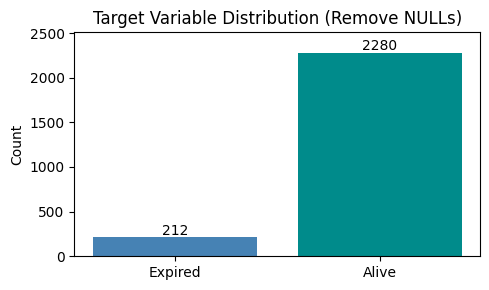

In [93]:
import matplotlib.pyplot as plt

# Filters patient table to non-null labels, then counts distinct patientunitstayid per label value using GROUP BY.
labels_df = con.execute(f"""
    SELECT hospitaldischargestatus AS label, COUNT(*) AS n
    FROM sqlite_scan('{SQLITE_DB}', 'patient')
    WHERE hospitaldischargestatus IS NOT NULL
      AND TRIM(hospitaldischargestatus) <> ''
    GROUP BY hospitaldischargestatus
""").df()

# Class imbalance bar chart
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(labels_df["label"], labels_df["n"], color=["steelblue", "darkcyan"])
ax.set_ylabel("Count")
ax.set_title("Target Variable Distribution (Remove NULLs)")
for i, row in labels_df.iterrows():
    ax.text(i, row["n"] + 30, str(row["n"]), ha="center", fontsize=10)
ax.set_ylim(0, labels_df["n"].max() * 1.1)
plt.tight_layout()
plt.show()

<span style="color:red">**Takeaway:** </span> 
90.5% Alive / 8.4% Expired with 28 null labels.
Heavily imbalanced. Requires stratified splits, class weighting, and
evaluation on AUROC / F1 rather than accuracy. Null labels will be
dropped from training.

### Feature table coverage per stay

Not all patients have entries in every table. Tables with low coverage
contribute sparse features and may not justify inclusion. This identifies
which tables to prioritize in feature engineering.

In [94]:
# Count total ICU stays in the dataset (denominator for coverage)
total_stays = con.execute(f"""
    SELECT COUNT(DISTINCT patientunitstayid) AS n
    FROM sqlite_scan('{SQLITE_DB}', 'patient')
""").df().iloc[0, 0]

# For each table in the final feature set, check what percentage of
# stays have at least one row. Low-coverage tables contribute sparse
# features and may not justify inclusion in the model.
feature_tables = feature_set["table_name"].unique()

coverage = []
for t in feature_tables:
    n = con.execute(f"""
        SELECT COUNT(DISTINCT patientunitstayid) AS n
        FROM sqlite_scan('{SQLITE_DB}', '{t}')
    """).df().iloc[0, 0]
    coverage.append({
        "table_name": t, 
        "stays_with_data": n, 
        "pct_coverage": round(n / total_stays * 100, 1)
    })

pd.DataFrame(coverage).sort_values("pct_coverage", ascending=False).reset_index(drop=True)

,table_name,stays_with_data,pct_coverage
0,patient,2520,100.0
1,careplangeneral,2455,97.4
2,lab,2444,97.0
3,nursecharting,2395,95.0
4,note,2257,89.6
5,admissiondx,2221,88.1
6,physicalexam,2217,88.0
7,pasthistory,2211,87.7
8,intakeoutput,2185,86.7
9,diagnosis,2155,85.5


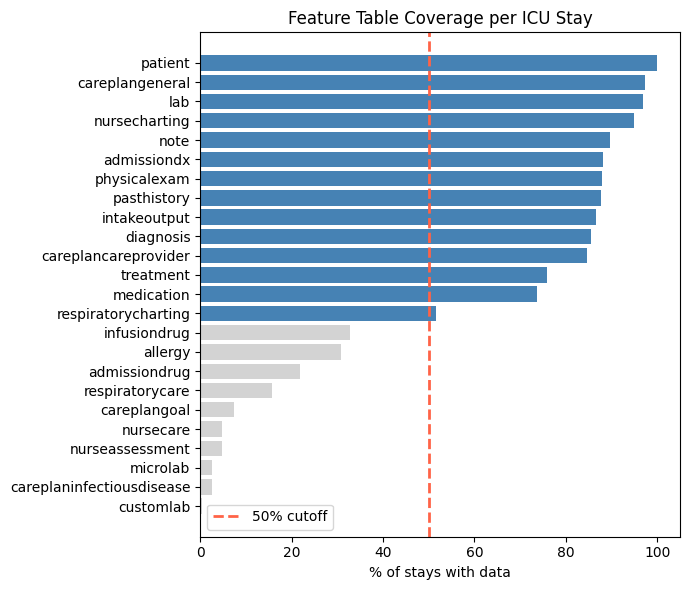

In [95]:
# Coverage by table (horizontal bar chart)
coverage_df = pd.DataFrame(coverage).sort_values("pct_coverage", ascending=True)

fig, ax = plt.subplots(figsize=(7, 6))
colors = ["steelblue" if x >= 50 else "lightgray" for x in coverage_df["pct_coverage"]]
ax.barh(coverage_df["table_name"], coverage_df["pct_coverage"], color=colors)
ax.axvline(x=50, color="tomato", linestyle="--", linewidth=2, label="50% cutoff")
ax.set_xlabel("% of stays with data")
ax.set_title("Feature Table Coverage per ICU Stay")
ax.legend()
plt.tight_layout()
plt.show()

<span style="color:red">**Takeaway:** </span> 
Tables with ≥ 50% coverage are included in feature engineering.
Tables below 50% cover too few stays to contribute meaningful
signal in a dataset of ~2,500 stays. Lower-coverage tables could
be added in a production setting with more data.

### Row volume per stay

Tables with few rows per stay produce thin text after concatenation.
Tables with many rows produce denser features but also more noise.
This informs aggregation strategy and whether to apply row-level
filtering before concatenation.

In [96]:
# Subquery counts rows per patientunitstayid within each table,
# then the outer query computes summary statistics across those counts.
# Results are collected per table and assembled into a single dataframe.
row_volume = []
for t in feature_tables:
    stats = con.execute(f"""
        SELECT 
            ROUND(AVG(cnt), 1) AS avg_rows,
            MEDIAN(cnt) AS median_rows,
            MAX(cnt) AS max_rows
        FROM (
            SELECT patientunitstayid, COUNT(*) AS cnt
            FROM sqlite_scan('{SQLITE_DB}', '{t}')
            GROUP BY patientunitstayid
        )
    """).df()
    row_volume.append({"table_name": t, **stats.iloc[0].to_dict()})

pd.DataFrame(row_volume).sort_values("avg_rows", ascending=False).reset_index(drop=True)

,table_name,avg_rows,median_rows,max_rows
0,nurseassessment,750.7,451.0,3840.0
1,nursecharting,616.8,290.0,19264.0
2,nursecare,344.9,167.5,3256.0
3,lab,177.8,121.0,2727.0
4,respiratorycharting,135.2,28.0,9595.0
5,infusiondrug,46.3,13.0,1652.0
6,intakeoutput,46.0,18.0,1452.0
7,medication,40.7,33.0,314.0
8,physicalexam,37.9,23.0,1579.0
9,treatment,20.0,6.0,1668.0


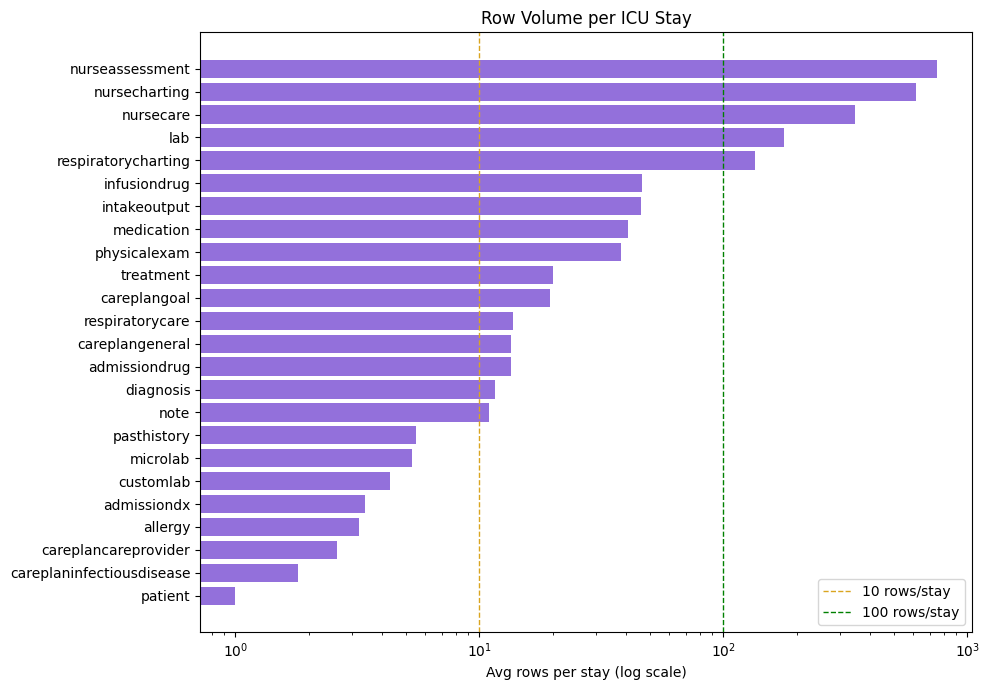

In [97]:
# Row volume per stay (horizontal bar chart)
# Log scale used because row counts span 3 orders of magnitude
# (1 row for patient to 750+ for nurseassessment), making linear
# scale unreadable for low-volume tables.
volume_df = pd.DataFrame(row_volume).sort_values("avg_rows", ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(volume_df["table_name"], volume_df["avg_rows"], color="mediumpurple")
ax.set_xscale("log")
ax.axvline(x=10, color="goldenrod", linestyle="--", linewidth=1, label="10 rows/stay")
ax.axvline(x=100, color="green", linestyle="--", linewidth=1, label="100 rows/stay")
ax.set_xlabel("Avg rows per stay (log scale)")
ax.set_title("Row Volume per ICU Stay")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

<span style="color:red">**Takeaway:** </span>
Row volume varies widely across tables, from 1 row per stay
(patient) to 750+ (nurseassessment). High-volume tables will produce
denser text after concatenation but may need row-level filtering to
reduce noise. This is combined with coverage data above to determine
which tables are worth including.

### Temporal offset distribution
Most feature tables include an offset column (minutes from ICU admission).
Filtering to an early time window (e.g., first 24 hours, offset ≤ 1440)
prevents using information that would not be available at prediction time.
<br><br>
This check shows what percentage of data is retained at the 24-hour
cutoff, informing whether the window needs to be widened.

In [98]:
# Tables without an offset column are skipped - those tables either represent static data (e.g., patient demographics) or will need separate temporal handling.
offset_check = []
for t in feature_tables:
    # Get column names for this table using schema-only query
    cols = [c[0].lower() for c in con.execute(
        f"SELECT * FROM sqlite_scan('{SQLITE_DB}', '{t}') LIMIT 0"
    ).description]
    offset_cols = [c for c in cols if "offset" in c]
    
    for oc in offset_cols:
        stats = con.execute(f"""
            SELECT
                COUNT(*) AS total_rows,
                SUM(CASE WHEN {oc} <= 1440 THEN 1 ELSE 0 END) AS rows_within_24h,
                ROUND(
                    SUM(CASE WHEN {oc} <= 1440 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 
                    1
                ) AS pct_retained
            FROM sqlite_scan('{SQLITE_DB}', '{t}')
        """).df()
        offset_check.append({
            "table_name": t, 
            "offset_column": oc, 
            **stats.iloc[0].to_dict()
        })

pd.DataFrame(offset_check)

,table_name,offset_column,total_rows,rows_within_24h,pct_retained
0,admissiondrug,drugoffset,7417.0,5506.0,74.2
1,admissiondrug,drugenteredoffset,7417.0,5464.0,73.7
2,allergy,allergyoffset,2475.0,2058.0,83.2
3,allergy,allergyenteredoffset,2475.0,2045.0,82.6
4,careplancareprovider,careprovidersaveoffset,5627.0,3896.0,69.2
5,careplangeneral,cplitemoffset,33148.0,25159.0,75.9
6,careplangoal,cplgoaloffset,3633.0,1566.0,43.1
7,careplaninfectiousdisease,cplinfectdiseaseoffset,112.0,60.0,53.6
8,diagnosis,diagnosisoffset,24978.0,12827.0,51.4
9,infusiondrug,infusionoffset,38256.0,12269.0,32.1


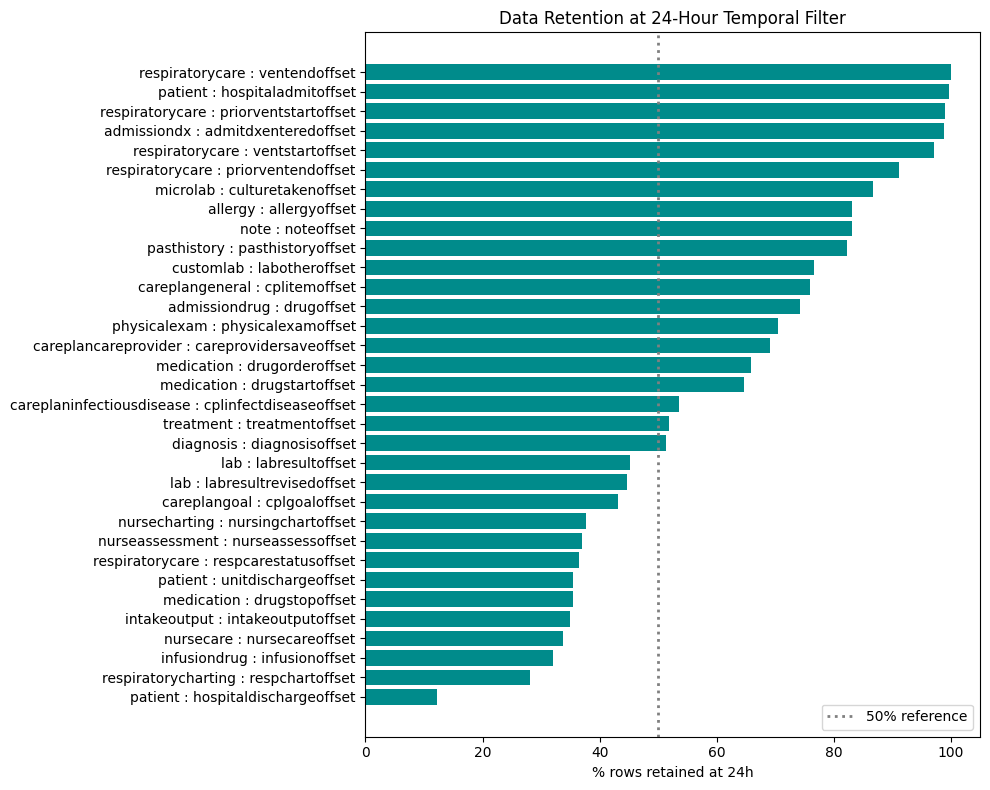

In [99]:
# Filter to primary clinical event offsets per table.
# Prefer non-entered/entry offsets, but if a table only has entered/entry offsets, keep them as the fallback.
offset_df = pd.DataFrame(offset_check)

# Identify tables that have at least one non-entered/entry offset.
# These tables have a "true" clinical event timestamp available.
has_clinical = set(
    offset_df[
        ~offset_df["offset_column"].str.contains("entered|entry", case=False)
    ]["table_name"]
)

# Keep non-entered/entry offsets for tables that have them.
# For tables that ONLY have entered/entry offsets (e.g., admissiondx with admitdxenteredoffset), include those as the fallback since
# they are the only temporal signal available.
clinical_offsets = offset_df[
    (~offset_df["offset_column"].str.contains("entered|entry", case=False))
    | (~offset_df["table_name"].isin(has_clinical))
].sort_values(["table_name", "pct_retained"], ascending=[True, True])

# Sort by retention for chart readability
plot_df = clinical_offsets.sort_values("pct_retained", ascending=True)

# Horizontal bar chart showing what percentage of each table's rows fall within the first 24 hours (offset ≤ 1440 minutes)
fig, ax = plt.subplots(figsize=(10, 8))
labels = plot_df["table_name"] + " : " + plot_df["offset_column"]
ax.barh(labels, plot_df["pct_retained"], color="darkcyan")
ax.axvline(x=50, color="gray", linestyle=":", linewidth=2, label="50% reference")
ax.legend(loc="lower right")
ax.set_xlabel("% rows retained at 24h")
ax.set_title("Data Retention at 24-Hour Temporal Filter")
plt.tight_layout()
plt.show()

<span style="color:red">**Takeaway:** </span>
A 24-hour cutoff (offset ≤ 1440 minutes) is used for temporal filtering.
Retention is acceptable for primary text tables (admissiondx 99%,
pasthistory 82%, note 83%, diagnosis 51%).
Most high-coverage text tables retain 50%+ of rows at this cutoff.
Tables with lower retention (nursecharting ~37%, lab ~45%) are
expected to accumulate throughout the stay.

### Export feature set for model development

The included tables and their classified text columns are written to a
CSV file so the model development notebook can load them directly
without re-running exploration or hardcoding table names, fields or buckets.

In [100]:
# Filter to tables meeting the 50% coverage threshold
included_tables = set(
    pd.DataFrame(coverage)
    .query("pct_coverage >= 50")["table_name"]
)

# Subset the feature set to only included tables,
# keeping the column name and bucket for routing in feature engineering
included_features = feature_set[
    feature_set["table_name"].isin(included_tables)
][["table_name", "column_name", "final_bucket"]]

# Write to processed data directory as a handoff artifact
# between exploration and model development
output_path = PROJECT_ROOT / "data" / "processed"
output_path.mkdir(parents=True, exist_ok=True)
included_features.to_csv(output_path / "feature_set.csv", index=False)

## Exploration summary and feature engineering scope

**Target variable:** 90.5% Alive / 8.4% Expired (28 null labels to drop).
Heavily imbalanced: stratified splits, class weighting, evaluate on
AUROC / F1 rather than accuracy.
<br><br>

**Feature scope (NLP-focused):**
- Text features from narrative, mixed, hierarchical, and categorical
  buckets will form the core of the model
- Demographics (age, gender, unit_type) included as lightweight context,
  consistent with the API specification
- Numeric and boolean fields are excluded from the modeling pipeline
  (out of scope for an NLP approach, not harmful/leakage)
<br><br>

**Tables included** (coverage ≥ 50%):
patient, careplangeneral, lab, nursecharting, note, admissiondx,
physicalexam, pasthistory, intakeoutput, diagnosis, careplancareprovider,
treatment, medication, respiratorycharting
<br><br>

**Tables excluded** (coverage < 50%):
infusiondrug, allergy, admissiondrug, respiratorycare, careplangoal,
nursecare, nurseassessment, careplaninfectiousdisease, microlab, customlab.
Lower-coverage tables could be added in a production setting with more data.
<br><br>

**Temporal filter:** First 24 hours (offset ≤ 1440 minutes).
Most high-coverage text tables retain 50%+ of rows at this cutoff.
<br><br>

**Aggregation approach:**
- Multiple rows per stay are concatenated into a single text
  representation per patientunitstayid
- Categorical fields: distinct values collected into a space-separated string
- Mixed/narrative fields: all values concatenated, ordered by offset
- Hierarchical fields: delimiters replaced with spaces to produce
  clean tokens for TF-IDF
<br><br>

**Leakage controls:**
- Apache-derived tables excluded entirely (apacheapsvar, apachepredvar,
  apachepatientresult)
- Apache admission diagnosis removed (directly encodes mortality risk)
- All discharge-time fields removed (target variable, discharge status,
  discharge location, activeupondischarge flags)
- Temporal filtering to first 24 hours prevents using future information